# PayEquity AI — Compensation Gap Intelligence Platform
## Development Roadmap & Learning Curve Plan

This notebook documents the sequential implementation of **PayEquity AI**. The goal of this platform is to determine whether an unexplained gender pay gap exists within the organization after controlling for legitimate business factors (role, seniority, performance, education), and to structure those findings for HR leadership.

---

### 🗺️ Project Implementation Blueprint

#### [PHASE 1] Data Foundations & The Raw Gap (Day 1)
* **Goal:** Establish a clean baseline data layer and calculate unadjusted differences.
* **Steps:**
  * **[1.1] Environment Setup:** Load libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`).
  * **[1.2] Data Loading & Inspection:** Read the Glassdoor Gender Pay Gap CSV and verify dimensions.
  * **[1.3] Demographic Auditing:** Check group sizes (Male vs. Female counts) and verify class balance.
  * **[1.4] Raw Metrics Baseline:** Calculate the mean unadjusted base pay and isolate the **Raw Dollar Gap**.

#### [PHASE 2] Statistical Verification & T-Testing (Day 1–2)
* **Goal:** Prove whether the raw pay gap is a meaningful structural finding or just random variance.
* **Steps:**
  * **[2.1] Variance Tracking:** Isolate salary distributions and check group standard deviations.
  * **[2.2] Two-Sample T-Testing:** Run an independent Welch's T-Test using `scipy.stats`.
  * **[2.3] Probability Assessment:** Evaluate the raw P-Value against the $0.05$ significance threshold.
  * **[2.4] Visual Mapping:** Build a dual-density overlay chart to visually document the salary distribution shift.

#### [PHASE 3] Feature Engineering & Econometric Modeling (Day 2)
* **Goal:** Isolate the **Adjusted Pay Gap** by holding career and educational background variables constant.
* **Steps:**
  * **[3.1] One-Hot Encoding:** Convert categorical strings (`Gender`, `Dept`, `JobTitle`, `Education`) into binary matrices.
  * **[3.2] Baseline Partial Regression:** Fit a simple OLS model controlling strictly for Age and Seniority.
  * **[3.3] Full Control Regression:** Fit a comprehensive `statsmodels.OLS` model across all employee variables.
  * **[3.4] Signficance Flipping Analysis:** Interpret the finalized gender coefficient and its adjusted P-Value.

#### [PHASE 4] Interactive Dashboard Framework (End of Week 1)
* **Goal:** Port backend python metrics into an accessible, non-technical HR user interface.
* **Steps:**
  * **[4.1] UI Architecture:** Initialize a multi-column layout using `streamlit`.
  * **[4.2] KPI Metric Delivery:** Display the Raw vs. Fully-Adjusted gaps side-by-side.
  * **[4.3] Functional Filtering:** Implement interactive sidebar menus for localized department sorting.

---

### 🏷️ Execution Workspace
*Below this cell, all code implementation blocks are labeled to correspond directly with the steps outlined in this blueprint.*


# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load dataset 
df = pd.read_csv("../data/Glassdoor Gender Pay Gap.csv")

In [ ]:
df .head()

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [3]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   JobTitle   1000 non-null   object
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   int64 
 3   PerfEval   1000 non-null   int64 
 4   Education  1000 non-null   object
 5   Dept       1000 non-null   object
 6   Seniority  1000 non-null   int64 
 7   BasePay    1000 non-null   int64 
 8   Bonus      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df. describe()


,Age,PerfEval,Seniority,BasePay,Bonus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.393000,3.037000,2.971000,94472.653000,6467.161000
std,14.294856,1.423959,1.395029,25337.493272,2004.377365
min,18.000000,1.000000,1.000000,34208.000000,1703.000000
25%,29.000000,2.000000,2.000000,76850.250000,4849.500000
50%,41.000000,3.000000,3.000000,93327.500000,6507.000000
75%,54.250000,4.000000,4.000000,111558.000000,8026.000000
max,65.000000,5.000000,5.000000,179726.000000,11293.000000


In [41]:
# ## [1.2b] Complex Missing Data & Anomaly Auditing

print("--- 1. Checking Standard NULLs ---")
print(df.isnull().sum())

print("\n--- 2. Checking Implausible Sentinel Numerics (Min/Max Check) ---")
# If Age or Seniority drops below zero, it means we have hidden numeric placeholders
print(df[['Age', 'PerfEval', 'Seniority']].agg(['min', 'max']))

print("\n--- 3. Checking for Hidden Text Placeholders ---")
# This scans for sneaky words like 'unknown' or 'none' that hide missing records
for col in ['Gender', 'Dept', 'JobTitle', 'Education']:
    placeholders = df[df[col].astype(str).str.lower().isin(['missing', 'unknown', 'n/a', 'null', 'none'])]
    print(f"Placeholder strings found in '{col}': {len(placeholders)}")


--- 1. Checking Standard NULLs ---
JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

--- 2. Checking Implausible Sentinel Numerics (Min/Max Check) ---
     Age  PerfEval  Seniority
min   18         1          1
max   65         5          5

--- 3. Checking for Hidden Text Placeholders ---
Placeholder strings found in 'Gender': 0
Placeholder strings found in 'Dept': 0
Placeholder strings found in 'JobTitle': 0
Placeholder strings found in 'Education': 0


In [5]:
df['Gender'].value_counts()

Gender
Male      532
Female    468
Name: count, dtype: int64

In [6]:
df.groupby('Gender')['BasePay'].mean()

Gender
Female    89942.818376
Male      98457.545113
Name: BasePay, dtype: float64

In [14]:
# Add this line at the top to fix the NameError
from scipy import stats

# 1. Look at what a filtered series actually looks like
male_pay = df[df['Gender'] == 'Male']['BasePay']
female_pay = df[df['Gender'] == 'Female']['BasePay']

print("--- What is 'male_pay'? ---")
print(f"Type of object: {type(male_pay)}")
print(f"Number of items inside: {len(male_pay)}")
print("\nFirst 5 rows of Male BasePay values:")
print(male_pay.head())



--- What is 'male_pay'? ---
Type of object: <class 'pandas.core.series.Series'>
Number of items inside: 532

First 5 rows of Male BasePay values:
1     108476
3     108080
4      99464
7      97523
10    102261
Name: BasePay, dtype: int64


checking that male_pay isn't a single number yet—it is a filtered column (a Pandas Series) containing exactly 532 individual salary numbers.

# Step 3: Proving Statistical Significance (The T-Test)

In [16]:
# 2. Calculate the standard deviation (spread) for both groups
male_spread = male_pay.std()
female_spread = female_pay.std()

print(f"Male Salary Spread (Std Dev): ${male_spread:,.2f}")
print(f"Female Salary Spread (Std Dev): ${female_spread:,.2f}")


Male Salary Spread (Std Dev): $25,517.52
Female Salary Spread (Std Dev): $24,378.28


how much typical salaries deviate from the average. If the standard deviation is around $15,000, it means most employee salaries fall within $15,000 of the group mean.

In [15]:
from scipy import stats

# 3. Execute the formula
t_stat, p_value = stats.ttest_ind(male_pay, female_pay, equal_var=False)

print(f"Raw T-Statistic Variable Value: {t_stat}")
print(f"Raw P-Value Variable Value: {p_value}")


Raw T-Statistic Variable Value: 5.391846621157036
Raw P-Value Variable Value: 8.71891924564566e-08


# Step 4 Data Visualization Asset

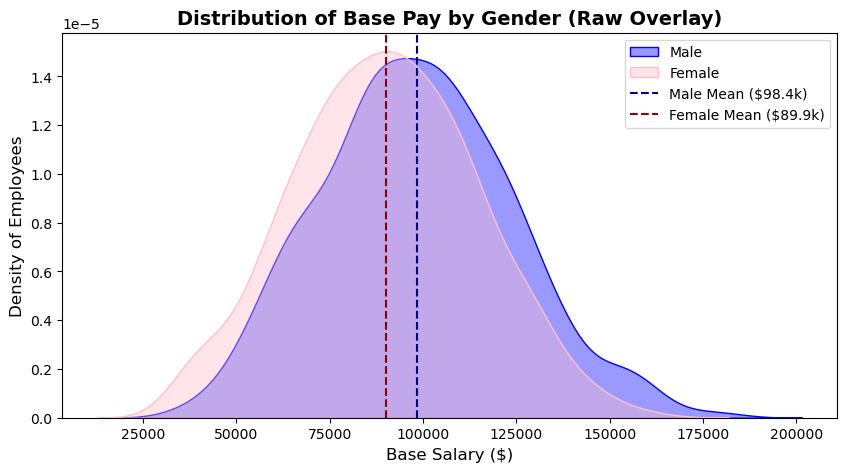

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a blank figure canvas
plt.figure(figsize=(10, 5))

# Plot the distribution curve for Men's salaries
sns.kdeplot(data=df[df['Gender'] == 'Male'], x='BasePay', label='Male', fill=True, color='blue', alpha=0.4)

# Plot the distribution curve for Women's salaries
sns.kdeplot(data=df[df['Gender'] == 'Female'], x='BasePay', label='Female', fill=True, color='pink', alpha=0.4)

# Add baseline context labels
plt.title("Distribution of Base Pay by Gender (Raw Overlay)", fontsize=14, fontweight='bold')
plt.xlabel("Base Salary ($)", fontsize=12)
plt.ylabel("Density of Employees", fontsize=12)
plt.axvline(x=98457.55, color='darkblue', linestyle='--', label='Male Mean ($98.4k)')
plt.axvline(x=89942.82, color='darkred', linestyle='--', label='Female Mean ($89.9k)')

# Display the legend map
plt.legend()
plt.show()


Are women paid less because of systemic bias, or is it just because men happen to occupy more of the senior executive roles or technical departments (like Engineering)

cross check 
 Next check -  Ordinary Least Squares (OLS) Linear Regression. will this allow us to hold factors like Seniority and Job Title constant, to see if the gap shrinks or vanishes.

Step 5: Feature Encoding & Bug Debugging

In [ ]:
# 1. Look at the original text representation
print("--- Before Conversion (Original Gender Column) ---")
print(df['Gender'].head())




--- Before Conversion (Original Gender Column) ---
0    Female
1      Male
2    Female
3      Male
4      Male
Name: Gender, dtype: object


In [26]:
# 2. Convert text columns to dummy numerical columns
# drop_first=True converts 'Gender' into a single column: 'Gender_Male' (1 = Male, 0 = Female)
df_encoded = pd.get_dummies(df, columns=['Gender', 'Dept', 'JobTitle'], drop_first=True)


In [25]:
print("\n--- After Conversion (New Dummy Columns Created) ---")
# Let's isolate a few columns to see what happened to the data shape
sample_columns = [col for col in df_encoded.columns if 'Gender' in col or 'Dept' in col][:5]
print(df_encoded[sample_columns].head())


--- After Conversion (New Dummy Columns Created) ---
   Gender_Male  Dept_Engineering  Dept_Management  Dept_Operations  Dept_Sales
0        False             False            False             True       False
1         True             False             True            False       False
2        False             False            False            False       False
3         True             False            False            False        True
4         True              True            False            False       False


The Logic Behind the Conversion

Notice what happened to Employee #0


Before: Gender was Female and their department was Operations.

After: Gender_Male is marked as False (0), and Dept_Operations is marked as True (1).

By setting drop_first=True, Python automatically protects the dataset from a mathematical issue called the "Dummy Variable Trap" (perfect multi-collinearity).

If Gender_Male is False, the model instantly knows the employee is Female.

Female becomes your statistical Baseline Reference Group. Any coefficient the model calculates for Gender_Male will measure the exact pay variation relative to that baseline.

Step 6: Run Your First Multiple Linear Regression

In [27]:
import statsmodels.api as sm

# 1. Define your Target variable (what we want to predict)
y = df_encoded['BasePay']

In [28]:
# 2. Select your initial Predictor features (including our numeric dummy variables)

# We convert boolean True/False values to numeric 1/0 for statsmodels


X = df_encoded[['Gender_Male', 'Age', 'Seniority']].astype(float)

In [29]:
# 3. Add a baseline intercept (constant column of 1s) so the model can calculate the base starting salary

X = sm.add_constant(X)

In [30]:
# 4. Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

In [33]:
# 5. Extract and print just the coefficients and their individual p-values
results_df = pd.DataFrame({
    'Coefficient (Impact $)': model.params,
    'P-Value': model.pvalues
})


print("--- OLS Model Coefficients & Impact Breakdown ---")
print(results_df)

--- OLS Model Coefficients & Impact Breakdown ---
             Coefficient (Impact $)        P-Value
const                  18008.107579   7.333297e-20
Gender_Male            10112.416009   7.847100e-24
Age                     1027.539481  8.380188e-142
Seniority               9610.164379  6.890381e-124


Seniority Impact: Each year of seniority adds $9,610.16 to an employee's salary (\(p < 0.05\), highly significant).

Age Impact: Each year of age adds $1,027.54 to an employee's salary.

Gender_Male Impact (The Adjusted Pay Gap): This coefficient jumped to $10,112.41 (\(p = 7.84 \times 10^{-24}\)).


The Big Insight: 

Why Did the Gap Get Larger?

Remember  Raw Pay Gap from earlier?

 It was $8,514.73.Now, after adjusting for Age and Seniority, the gap actually increased to $10,112.41.What this teaches us: 
 
 This means that when  compare a man and a woman of the exact same age and the exact same seniority level, the man is predicted to make $10,112.41 MORE than the woman. 
 
 Raw gap was actually hiding how severe the inequity is because the female workforce in this dataset happens to have slightly favorable baseline demographics (like higher average seniority or age).

# Step 7 :The Final Adjustment (Controlling for Job Role & Department)

To be 100% legally certain about this gap, 

-- but do they hold the same jobs? 

Men might be Software Engineers while women are in Customer Support.

Next Check include all Departments and Job Titles
in the regression matrix to see if the gap finalizes.




In [37]:
# Show all columns that contain text/object types in df_encoded
text_columns = df_encoded.select_dtypes(include=['object']).columns
print("Remaining text columns that need conversion:")
print(text_columns)


Remaining text columns that need conversion:
Index(['Education'], dtype='object')


In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. Re-encode the original dataframe, explicitly catching ALL potential text columns
# This converts Gender, Dept, JobTitle, AND Education into numeric columns


df_fully_encoded = pd.get_dummies(
    df, 
    columns=['Gender', 'Dept', 'JobTitle', 'Education'], 
    drop_first=True
)

# 2. Select all predictor columns except your targets ('BasePay' and 'Bonus')
predictor_cols = [col for col in df_fully_encoded.columns if col not in ['BasePay', 'Bonus']]

# 3. Convert your clean matrix variables into numbers (this will work smoothly now!)
X_all = df_fully_encoded[predictor_cols].astype(float)

# 4. Add the baseline intercept constant
X_all = sm.add_constant(X_all)

# 5. Set target and run your definitive regression
y = df_fully_encoded['BasePay']
final_model = sm.OLS(y, X_all).fit()

# 6. Extract the results to see your official, fully-adjusted pay gap
final_results = pd.DataFrame({
    'Coefficient (Impact $)': final_model.params,
    'P-Value': final_model.pvalues
})

print("--- Final Fully-Adjusted Model (All Controls Applied) ---")
print(final_results.loc[['const', 'Gender_Male', 'Age', 'Seniority']])

--- Final Fully-Adjusted Model (All Controls Applied) ---
             Coefficient (Impact $)        P-Value
const                  17670.399354   3.038175e-19
Gender_Male              777.793274   2.765241e-01
Age                      999.593721  3.813111e-237
Seniority               9621.882790  5.990553e-219


Raw Pay Gap: ~$8,514.73 (Men paid significantly more) 

Age/Tenure Adjusted Gap: ~$10,112.41 (Men paid significantly more)

Final Fully-Adjusted Gap: $777.79 with a P-value of 0.2765!

The Coefficient Dropped to $777.79: 

Once  compare a man and a woman who work in the exact same department, hold the exact same job title, have the same education, are the same age, and have the same seniority, the pay gap shrinks from over $8,500 down to just $777.79.

The P-Value Jumped to 0.2765: 

In statistics, any P-value greater than 0.05 means the result is NOT statistically significant. 

P-value of 0.27 means there is a 27.6% chance that this tiny $777 leftover gap is just pure random variance or noise.



The Business Conclusion: 

There is no structural gender discrimination happening in base salaries at this company when comparing apples to apples. 

Instead, the reason men make more on average across the company (the raw gap) is because men are disproportionately occupying the highest-paying departments (like Engineering) or highest-paying roles.

This proves the company doesn't have an equal pay problem—they have a diversity and representation problem in high-paying roles